-------------------------------------
# **REDES NEURONALES**
________________________________

# 🚩 CNN
### Convolutional Neural Networks (Redes Nueronales Convolucionales)

Permite el análisis de imágenes mediante los píxeles cercanos.
> Utiliza pequeños filtros llamados *kernels*, que recorren la imagen en búsqueda de determinados patrones.

## Componentes clave:
a) Convolución (Conv2D)
  *  Aplica filtros (kernels) para obtener mapas de características.
  * Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

b) Activación (ReLU)
  * Introduce no linealidad.
  * ReLU(x) = max(0, x) suele funcionar muy bien.
> Si el valor es negativo --> 0.
> Si es positivo --> lo deja igual

c) Pooling (MaxPool)
  * Reduce resolución espacial, mantiene información importante.
  * Ayuda a generalización y reduce costo computacional.

d) Capas fully-connected (densas)
  * Integran la información para clasificación/regresión.

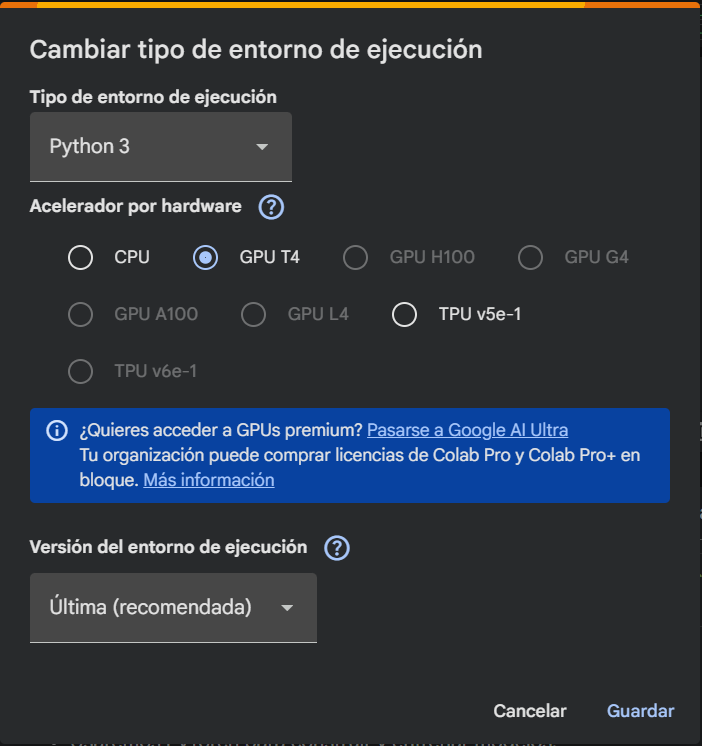

In [1]:
import sys
import subprocess

## 1. Preparación del entorno
* Usaremos PyTorch para construir y entrenar modelos.

In [2]:
packages = [
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm",
    "pillow"
]

for p in packages:
    subprocess.check_call([
        sys.executable, "-m", "pip",
        "install", "-q", p
    ])

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Cargar el dataset (TrashNet)
Conjunto de imágenes para la clasificación automática de residuos.
* Entrada: imágenes 2D de vidrio y plástico a escala de grises.
* Etiquetas: clasificación binaria.
  * (0) Vidrio
  * (1) Plástico
* Particiones: Las imágenes se dividen en conjuntos de *train, validation y test* mediante **trash_dataset.py**

In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

from trash_dataset import TrashDataset

data_flag = "trashnet" # ¿qué datase estamos usando?
DATA_DIR = "trashnet"  # ¿dónde están físicamente los datos?

DataClass = TrashDataset
DataClass.classes

['glass', 'plastic']

Vamos a copiar un repositorio

In [6]:
!git clone https://github.com/garythung/trashnet.git
!ls trashnet

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 12), reused 6 (delta 6), pack-reused 27 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 38.46 MiB/s, done.
Resolving deltas: 100% (14/14), done.
data		LICENSE    plot.lua   shuffle.lua  train.lua  weight-init.lua
DataLoader.lua	model.lua  README.md  test.lua	   utils.lua


In [7]:
import os
!find /content -maxdepth 3 -type d | head -50

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.09.04
/content/.config/configurations
/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/MI PORTAFOLIO - DPyA - Bustos Montañez Melissa
/content/drive/MyDrive/Fundamento de Programación
/content/drive/MyDrive/Informes de Bio
/content/drive/MyDrive/Fundamentos de Diseño
/content/drive/MyDrive/Informes de OPU
/content/drive/MyDrive/Apuntes - Ciclo V
/content/drive/MyDrive/Informes de PM
/content/drive/MyDrive/Informes de Ing. de Métodos
/content/drive/MyDrive/Proyectos finales - Ciclo V
/content/drive/MyDrive/Examen parcial - final - EyP
/content/drive/MyDrive/Ciclo 6
/content/drive/Shareddrives
/content/drive/.Trash-0
/content/drive/.Trash-0/files
/content/drive/.Trash-0/info
/content/trashnet
/content/trashnet/data
/content/trashnet/.git
/content/trashnet/.git/branches
/content/trashnet/.git/logs
/content/trashnet/.git/re

In [8]:
!wget -q https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip \
    -O /content/dataset-resized.zip

!unzip -q /content/dataset-resized.zip -d /content/

In [9]:
!find /content/dataset-resized -maxdepth 2 -type d

/content/dataset-resized
/content/dataset-resized/trash
/content/dataset-resized/paper
/content/dataset-resized/cardboard
/content/dataset-resized/metal
/content/dataset-resized/plastic
/content/dataset-resized/glass


In [10]:
DATA_DIR = "/content/dataset-resized"
# lo cambiamos porque ya sabemos dónde está

In [11]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(
    root=DATA_DIR,
    split="train",
    transform=transform_basic)

val_dataset = DataClass(
    root=DATA_DIR,
    split="val",
    transform=transform_basic)

test_dataset = DataClass(
    root=DATA_DIR,
    split="test",
    transform=transform_basic)

len(train_dataset), len(val_dataset), len(test_dataset)

(687, 147, 149)

## 3. Visualizar ejemplos

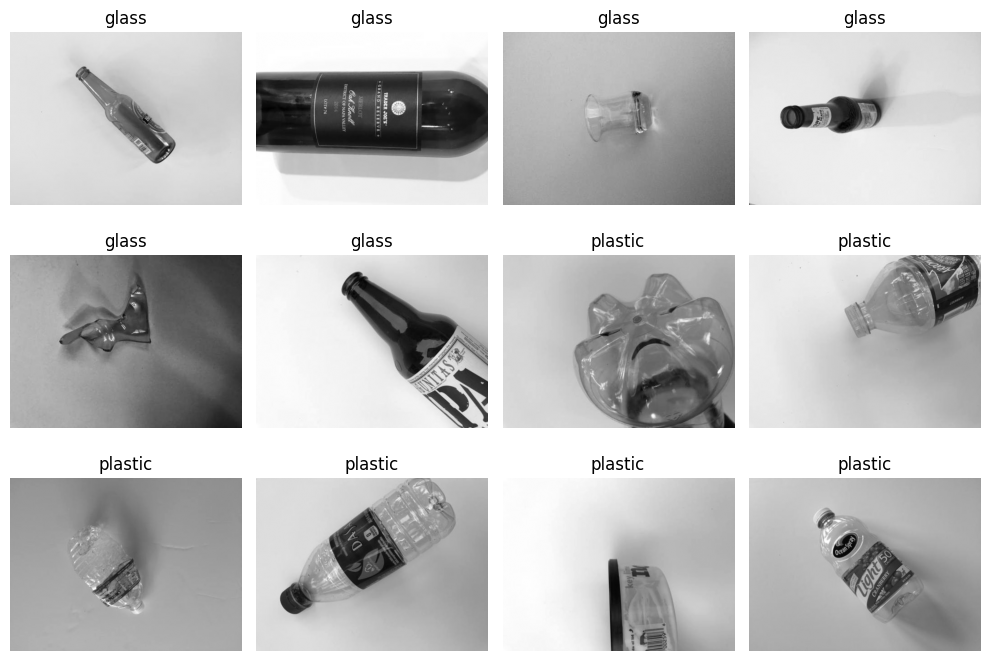

In [12]:
def show_glass_plastic(dataset):

    glass = []
    plastic = []

    for i in range(len(dataset)):
        x, y = dataset[i]
        label = int(y.item())

        if label == 0 and len(glass) < 6:
            glass.append((x, label))

        elif label == 1 and len(plastic) < 6:
            plastic.append((x, label))

        if len(glass) == 6 and len(plastic) == 6:
            break

    plt.figure(figsize=(10, 7))

    images = glass + plastic

    for i, (x, label) in enumerate(images):
        plt.subplot(3, 4, i + 1)
        img = x.squeeze(0)
        plt.imshow(img, cmap="gray")
        plt.title(DataClass.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_glass_plastic(train_dataset)

## 4. Preparar DataLoaders y device
* DataLoaders: Maneja batching y shuffle
* Device: Permite usar GPU si existe

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ¿Hay un GPU disponible para usar CUDA?
# si está disponible usar "cuda", sino "cpu"
device

device(type='cuda')

> La GPU es un procesador especializado que puede realizar muchas operaciones en paralelo, por lo que resulta muy útil para entrenar redes neuronales como las CNN.

In [14]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([128, 1, 384, 512]), torch.Size([128]))

## 5. Modelo 1: CNN entrenada desde cero
Construiremos una CNN básica y razonable:
* Bloques conv + ReLU + pooling.
* Al final, un clasificador.

In [15]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(DataClass.classes)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación
* Accuracy (porcentaje correcto)
* ROC-AUC (capacidad de separar clases)
* Matriz de confusión
* Precision/Recall/F1 (útiles cuando hay desbalance)


In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

def logits_to_probs(logits):
    if logits.shape[1] == 1:
        return torch.sigmoid(logits).squeeze(1)
    return torch.softmax(logits, dim=1)[:, 1]

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)
        probs = logits_to_probs(logits)
        preds = (probs >= 0.5).long()

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return acc, auc, y_true, y_pred, y_prob

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))

### 5.2. Entrenar el modelo desde cero

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 8
history_scratch = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6940 | val_acc=0.5102 | val_auc=0.5791
Epoch 02 | train_loss=0.6926 | val_acc=0.5102 | val_auc=0.6339
Epoch 03 | train_loss=0.6925 | val_acc=0.5102 | val_auc=0.6957
Epoch 04 | train_loss=0.6918 | val_acc=0.5102 | val_auc=0.6841
Epoch 05 | train_loss=0.6919 | val_acc=0.5102 | val_auc=0.7080
Epoch 06 | train_loss=0.6911 | val_acc=0.5034 | val_auc=0.7183
Epoch 07 | train_loss=0.6890 | val_acc=0.4762 | val_auc=0.7176
Epoch 08 | train_loss=0.6880 | val_acc=0.4898 | val_auc=0.7072


### 5.3. Curvas de entrenamiento
Visualizamos la pérdida y métricas para detectar el sobreajuste

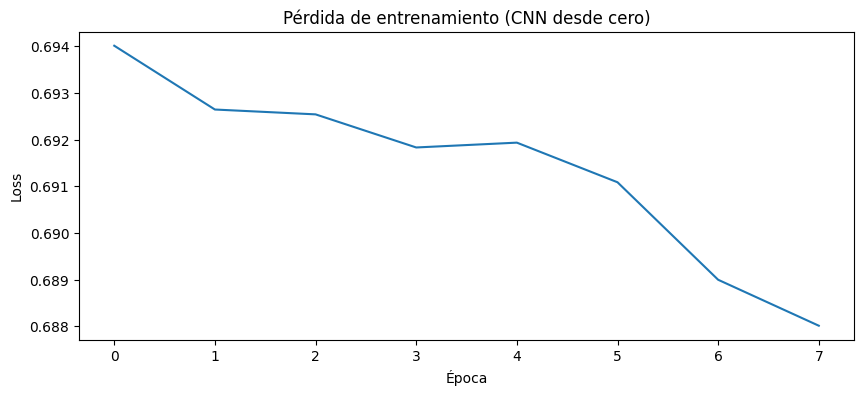

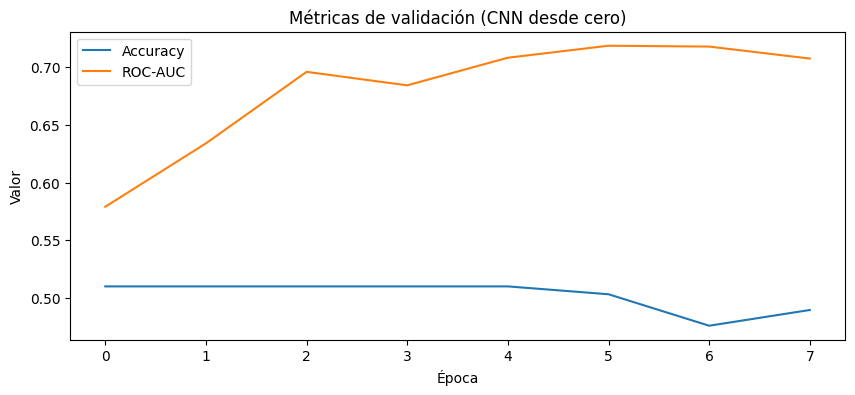

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"])
plt.title("Pérdida de entrenamiento (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Accuracy")
plt.plot(history_scratch["val_auc"], label="ROC-AUC")
plt.title("Métricas de validación (CNN desde cero)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.show()

* A partir de la época 4 comienza a clasificar con mayor exactitud hasta alcanzar un 63.27%
* Hay evidencia de aprendizaje moderada:
  * El ROC-AUC se mantiene alrededor de 0.67 - 0.69_ diferencia glass de plastic, pero la mejora es gradual
* La pérdida va disminuyendo

### 5.4. Evaluación final en test

In [19]:
test_acc, test_auc, y_true, y_pred, y_prob = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm

Test accuracy: 0.5034
Test ROC-AUC:  0.6725

              precision    recall  f1-score   support

           0     0.5068    0.9868    0.6696        76
           1     0.0000    0.0000    0.0000        73

    accuracy                         0.5034       149
   macro avg     0.2534    0.4934    0.3348       149
weighted avg     0.2585    0.5034    0.3416       149



array([[75,  1],
       [73,  0]])

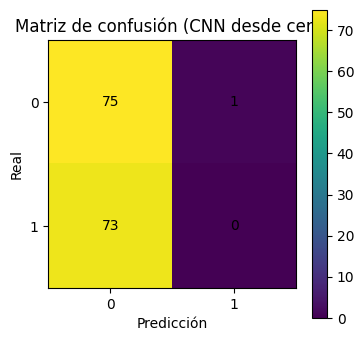

In [20]:
plt.figure(figsize=(4, 4))
plt.imshow(cm)
plt.title("Matriz de confusión (CNN desde cero)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1])
plt.yticks([0, 1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()

### 6. Data augmentation (aumento de datos)
Ayuda a generalizar, pero debe ser aplicado con cuidado:
* Rotaciones pequeñas y traslaciones suaves
> Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio

In [21]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(
    root=DATA_DIR,
    split="train",
    transform=transform_aug
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [22]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Epoch 01 | train_loss=0.6954 | val_acc=0.5102 | val_auc=0.6080
Epoch 02 | train_loss=0.6922 | val_acc=0.5102 | val_auc=0.7108
Epoch 03 | train_loss=0.6931 | val_acc=0.5102 | val_auc=0.7154
Epoch 04 | train_loss=0.6909 | val_acc=0.4830 | val_auc=0.7076
Epoch 05 | train_loss=0.6892 | val_acc=0.5850 | val_auc=0.6928
Epoch 06 | train_loss=0.6882 | val_acc=0.4966 | val_auc=0.6985


### 6.1. Comparación rápida

In [23]:
test_acc_aug, test_auc_aug, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")

Sin augmentation  | test_acc=0.5034 | test_auc=0.6725
Con augmentation  | test_acc=0.5235 | test_auc=0.6633


## 7. Transfer Learning
El transfer learning consiste en reutilizar un modelo entrenado en un dataset grande.

Ventajas:
* Suele mejorar el rendimiento con pocos datos

In [24]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1))
])

train_dataset_tl = DataClass(root=DATA_DIR, split="train", transform=transform_tl_train)
val_dataset_tl = DataClass(root=DATA_DIR, split="val", transform=transform_tl_eval)
test_dataset_tl = DataClass(root=DATA_DIR, split="test", transform=transform_tl_eval)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape

torch.Size([64, 3, 224, 224])

### 7.1. Construir el model preentrenado
* Entrenar solo la última capa

In [25]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage1 Epoch 01 | train_loss=0.8065 | val_acc=0.5034 | val_auc=0.4917
Stage1 Epoch 02 | train_loss=0.7090 | val_acc=0.5850 | val_auc=0.6050
Stage1 Epoch 03 | train_loss=0.6519 | val_acc=0.7007 | val_auc=0.7007
Stage1 Epoch 04 | train_loss=0.6166 | val_acc=0.6667 | val_auc=0.7467


* Hay un mejor aprendizaje
* El modelo está mejorando su capacidad para distinguir glass de plastic

### 7.2. Fine-tuning
Una práctica común es descongelar las últimas capas del extractor de características.

In [27]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)

17

In [28]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _ = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")

Stage2 Epoch 01 | train_loss=0.4780 | val_acc=0.7755 | val_auc=0.9017
Stage2 Epoch 02 | train_loss=0.2601 | val_acc=0.7891 | val_auc=0.9322
Stage2 Epoch 03 | train_loss=0.1621 | val_acc=0.8571 | val_auc=0.9533
Stage2 Epoch 04 | train_loss=0.1102 | val_acc=0.8776 | val_auc=0.9583


### 7.3. Evaluación en test del modelo con transfer learning

In [29]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl

Transfer learning | test_acc=0.8926 | test_auc=0.9551

              precision    recall  f1-score   support

           0     0.8659    0.9342    0.8987        76
           1     0.9254    0.8493    0.8857        73

    accuracy                         0.8926       149
   macro avg     0.8956    0.8918    0.8922       149
weighted avg     0.8950    0.8926    0.8924       149



array([[71,  5],
       [11, 62]])

### 7.4. Comparación global

In [30]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")

Resumen de resultados en test
CNN desde cero (sin aug)  | acc=0.5034 | auc=0.6725
CNN desde cero (con aug)  | acc=0.5235 | auc=0.6633
Transfer learning (ResNet) | acc=0.8926 | auc=0.9551


## 8. Interpretabilidad básica: Grad-CAM
Mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción
> Implementamos una versión simplificada para ResNet18

In [31]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


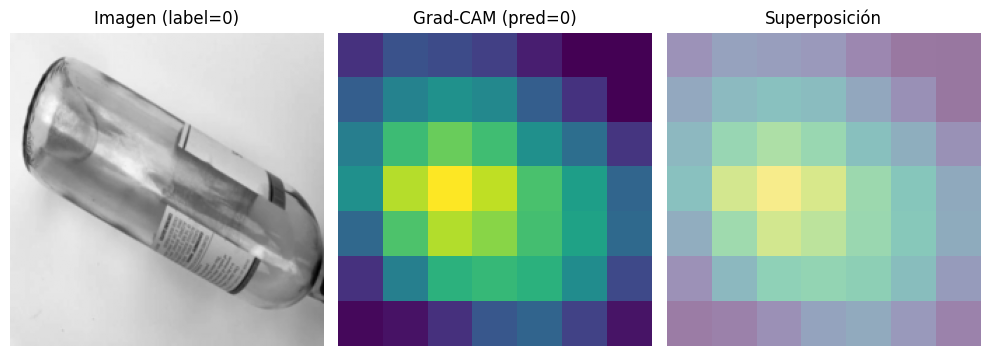

In [32]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

img = x[0].numpy()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Imagen (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam)
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img, cmap="gray")
plt.imshow(cam, alpha=0.5)
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()

* Las zonas más claras/amarillas del Grad-CAM representan mayor importancia para la predicción.
* En cambio, las zonas oscuras/moradas representan menor contribución.

## 9. Guardar y cargar modelos

In [33]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]

['models/cnn_scratch.pth', 'models/cnn_aug.pth', 'models/resnet_transfer.pth']

> Guarda para poder recuperarlos posteriormente sin tener que reentrenarlos



---



---



# 🚩 Clasificación binaria con Keras

* No tenemos que programar desde cero
* Nos permite construir y entrenar redes neuronales de una manera más sencilla.



> Tenemos reseñas de películas y queremos clasificarlas en dos categorías: positivas o negativas.



In [34]:
from keras.datasets import imdb
from keras import models, layers, optimizers
import numpy as np

## 1. Descargamos los datos de imdb - Keras

In [35]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000,index_from=3)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
train_data[0] # Primera reseña en secuencia de números

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [37]:
train_labels[0]
# 0: negativa
# 1: positiva

np.int64(1)

## 2. Diccionario de palabras

In [38]:
word_index = imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [40]:
word_index = dict([(value,key) for (key,value) in word_index.items()])
word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [41]:
for x in train_data[0]:
    print(word_index.get(x))
# vemos la información de la primera reseña

the
as
you
with
out
themselves
powerful
lets
loves
their
becomes
reaching
had
journalist
of
lot
from
anyone
to
have
after
out
atmosphere
never
more
room
and
it
so
heart
shows
to
years
of
every
never
going
and
help
moments
or
of
every
chest
visual
movie
except
her
was
several
of
enough
more
with
is
now
current
film
as
you
of
mine
potentially
unfortunately
of
you
than
him
that
with
out
themselves
her
get
for
was
camp
of
you
movie
sometimes
movie
that
with
scary
but
and
to
story
wonderful
that
in
seeing
in
character
to
of
70s
musicians
with
heart
had
shadows
they
of
here
that
with
her
serious
to
have
does
when
from
why
what
have
critics
they
is
you
that
isn't
one
will
very
to
as
itself
with
other
and
in
of
seen
over
landed
for
anyone
of
and
br
show's
to
whether
from
than
out
themselves
history
he
name
half
some
br
of
and
odd
was
two
most
of
mean
for
1
any
an
boat
she
he
should
is
thought
frog
but
of
script
you
not
while
history
he
heart
to
real
at
barrel
but
when
from
one
bit
then
have
tw

## 3. Función de one-hot encoding

In [42]:
def vectorizar(sequences, dim=10000):
    restults = np.zeros((len(sequences),dim))
    for i, sequences in enumerate(sequences):
        restults[i,sequences]=1
    return restults
# Creamos la transformación las reseñas en vectores 0 y 1
# 0: palabras ausentes
# 1: palabras presentes

## 4. Transformando datos

In [43]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

In [44]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## 5. Creación del modelo

In [45]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


* 2 capas ocultas de 16 neuronas
* 1 capa de salida con 1 neurona

In [46]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])


In [47]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train =  y_train[10000:]

In [48]:
modelb = model.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.7623 - loss: 0.5394 - val_accuracy: 0.8456 - val_loss: 0.4343
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8943 - loss: 0.3361 - val_accuracy: 0.8808 - val_loss: 0.3234
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9204 - loss: 0.2449 - val_accuracy: 0.8752 - val_loss: 0.3092
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9369 - loss: 0.1958 - val_accuracy: 0.8694 - val_loss: 0.3223
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9455 - loss: 0.1647 - val_accuracy: 0.8865 - val_loss: 0.2776
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9577 - loss: 0.1370 - val_accuracy: 0.8864 - val_loss: 0.2860
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9637 - loss: 0.1189 - val_accuracy: 0.8848 - val_loss: 0.2949
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9731 - loss: 0.0965 - val_accuracy: 0.8824 - 

## 6. Análisis del resultado

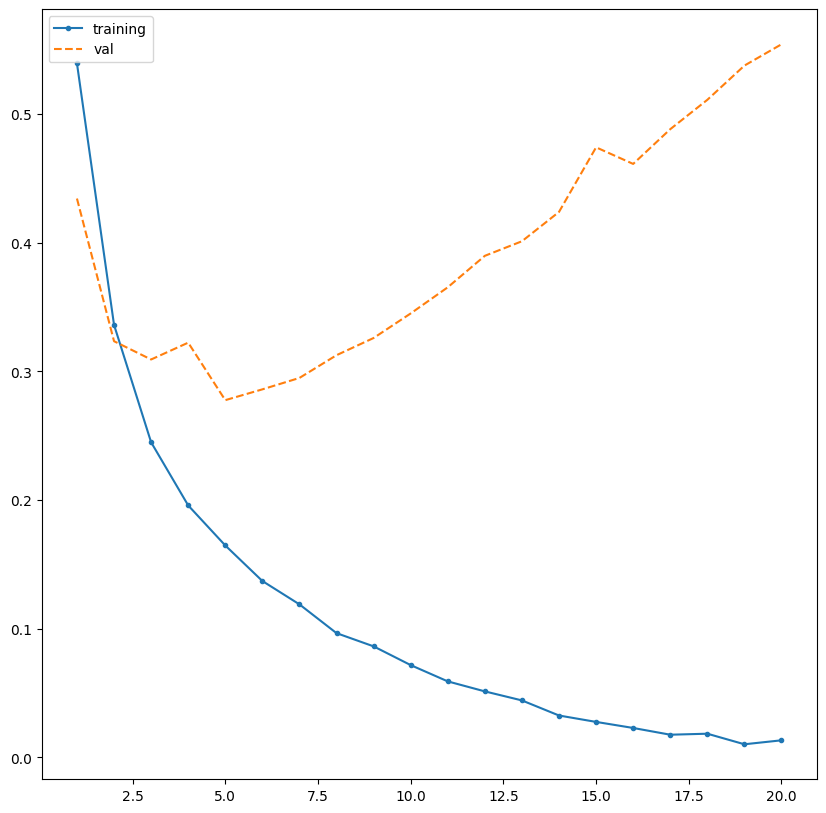

In [49]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,loss_values, '.-',label='training')
plt.plot(epoch,val_loss_values, '--',label='val')
plt.legend()
plt.show()

* Azul: error del modelo en entrenamiento
* Anaranjado: error sobre datos de validación

Vemos que la *curva anaranjada* no cae al final...
> Sobreajuste: la red está aprendiendo demasiado bien los datos de entrenamiento y pierde capacidad de generalización."

In [50]:
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8599 - loss: 0.5949


[0.594898521900177, 0.8599200248718262]

* Nivel de error: 0.6
* Exactitud: 86.1%

## 7. Comparando con un modelo más pequeño

In [51]:
model2 = models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
# Reducimos el número de neuronas
model2.add(layers.Dense(1, activation='sigmoid'))
model2.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])
modelb2 = model2.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.7589 - loss: 0.6050 - val_accuracy: 0.8332 - val_loss: 0.5332
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8647 - loss: 0.4795 - val_accuracy: 0.8589 - val_loss: 0.4522
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8859 - loss: 0.4012 - val_accuracy: 0.8614 - val_loss: 0.4028
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8983 - loss: 0.3467 - val_accuracy: 0.8748 - val_loss: 0.3614
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9086 - loss: 0.3060 - val_accuracy: 0.8772 - val_loss: 0.3380
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9171 - loss: 0.2746 - val_accuracy: 0.8829 - val_loss: 0.3155
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9225 - loss: 0.2495 - val_accuracy: 0.8882 - val_loss: 0.3005
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9284 - loss: 0.2292 - val_accuracy: 0.8896 - v

## 8. Analizamos resultados

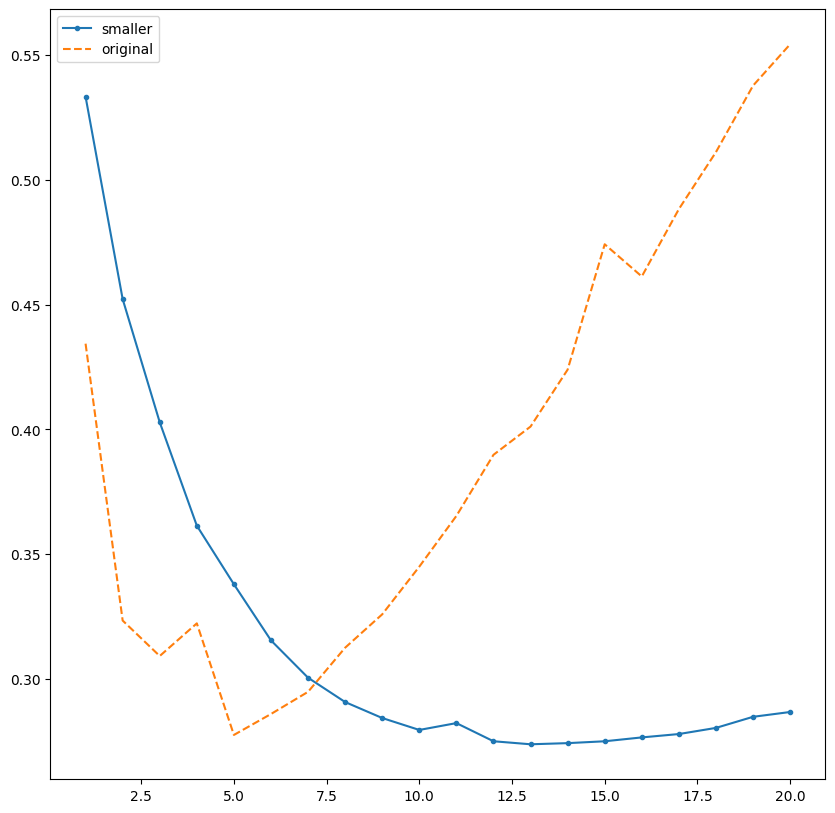

In [52]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values2 = modelb2.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values2, '.-',label='smaller')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

* Con la muestra original hubo un sobreajuste
* Con la muestra más pequeña el mínimo de pérdida se mantiene durante más épocas y el incremento posterior es mucho menor

> Existe sobreajuste, pero es menos pronunciado

## 9. Regularización

In [53]:
from keras import regularizers
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu', input_shape=(10000,),kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(16, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))
model3.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])
modelb3 = model3.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.7775 - loss: 0.5701 - val_accuracy: 0.8582 - val_loss: 0.4451
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8930 - loss: 0.3749 - val_accuracy: 0.8697 - val_loss: 0.3822
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9200 - loss: 0.3003 - val_accuracy: 0.8693 - val_loss: 0.3692
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9309 - loss: 0.2615 - val_accuracy: 0.8886 - val_loss: 0.3281
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9411 - loss: 0.2332 - val_accuracy: 0.8849 - val_loss: 0.3370
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9483 - loss: 0.2136 - val_accuracy: 0.8821 - val_loss: 0.3394
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9509 - loss: 0.2054 - val_accuracy: 0.8812 - val_loss: 0.3508
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9588 - loss: 0.1891 - val_accuracy: 0.8832 - 

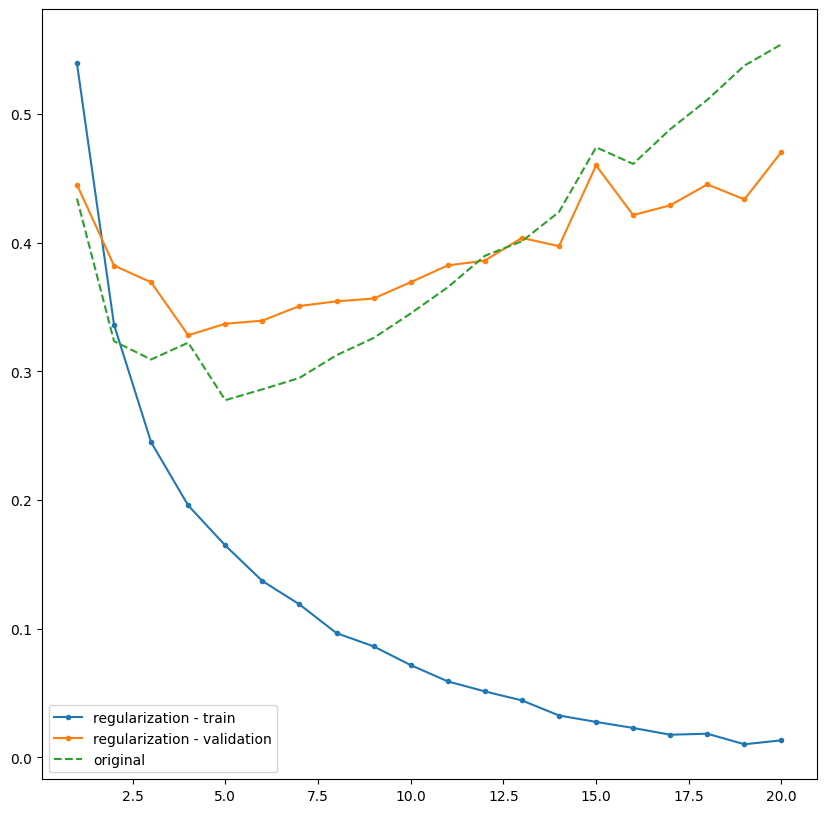

In [54]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values3 = modelb3.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,loss_values, '.-',label='regularization - train')
plt.plot(epoch,val_loss_values3, '.-',label='regularization - validation')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

Vemos un pico porque...
* El modelo aprende directamente de los datos de entrenamiento
* La regularización modifica el aprendizaje y puede producir un error más alto en algunas épocas

# 10. Dropout

In [55]:
model4 = models.Sequential()
model4.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(16, activation='relu'))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(1, activation='sigmoid'))
model4.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])
modelb4 = model4.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.6402 - loss: 0.6329 - val_accuracy: 0.8459 - val_loss: 0.5387
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7923 - loss: 0.5118 - val_accuracy: 0.8551 - val_loss: 0.4338
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8454 - loss: 0.4341 - val_accuracy: 0.8806 - val_loss: 0.3738
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8807 - loss: 0.3749 - val_accuracy: 0.8845 - val_loss: 0.3298
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8941 - loss: 0.3333 - val_accuracy: 0.8809 - val_loss: 0.3213
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9102 - loss: 0.2933 - val_accuracy: 0.8892 - val_loss: 0.2926
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9209 - loss: 0.2652 - val_accuracy: 0.8902 - val_loss: 0.2894
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9299 - loss: 0.2366 - val_accuracy: 0.8883 - 

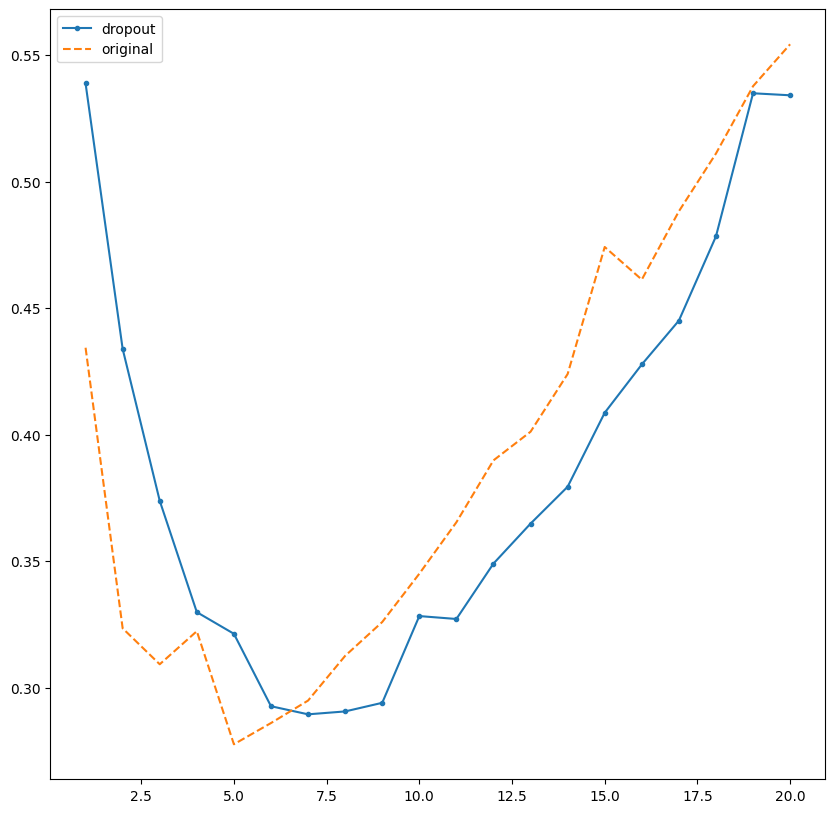

In [56]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values4 = modelb4.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values4, '.-',label='dropout')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

Para reducir el sobreajuste:
* Durante el entrenamiento se desactivan aleatoriamente el 50% de las neuronas
Ello obliga a la red a aprender de diferentes combinaciones de neuronas

# 11. Predicciones

In [57]:
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [58]:
predictions[10]

array([0.9627396], dtype=float32)

Nuestra predicción del índice 10 tiene un valor de 99.4%
> Reseña positiva con un 99.4% de probabilidad



---



---



# 🚩 Perceptrón

Modelo sencillo de inteligencia artificial que recibe datos, los combina mediante pesos y produce una salida (predicción).

In [59]:
import numpy as np

# Definir la función de activación escalón
# Convierte el resultado en 0 o 1
def step_function(x):
    return 1 if x >= 0 else 0

# Definir la función de activación tanh
# Transforma el valor de entrada de -1 a 1
def tanh_activation(x):
    return np.tanh(x)

# Definir la función del perceptrón
def perceptron(inputs, weights, bias, activation_func):
    # Calcular la suma ponderada de las entradas
    weighted_sum = np.dot(inputs, weights) + bias
    # Aplicar la función de activación
    output = activation_func(weighted_sum)
    return output

## 1. Factores

In [60]:
## ¿Qué factores influyen en el sobrecalentamiento de un equipo industrial?

temperatura = 100
vibracion = 50

# Pesos y sesgo (bias) del perceptrón
weights = np.array([0.5, -0.5])
bias = -30

# Establecemos las entradas del perceptrón
inputs = np.array([temperatura, vibracion])

## 2. Hacer funcionar el perceptrón

In [61]:
# Aplicar el perceptrón con función de activación escalón
output_step = perceptron(inputs, weights, bias, step_function)

# Aplicar el perceptrón con función de activación tanh
output_tanh = perceptron(inputs, weights, bias, tanh_activation)

## 3. Observamos resultados
* Diferencia de utilizar diferentes funciones de activación

In [62]:
# Imprimir resultados
print("Resultado usando función de activación escalón:")
print("Valor de salida:", output_step)
print("El equipo presenta una alerta de sobrecalentamiento." if output_step == 1 else "El equipo no presenta una alerta de sobrecalentamiento.")

print("\nResultado usando función de activación tanh:")
print("Valor de salida:", output_tanh)
print("El equipo presenta una alerta de sobrecalentamiento." if output_tanh >= 0 else "El equipo no presenta una alerta de sobrecalentamiento.")

Resultado usando función de activación escalón:
Valor de salida: 0
El equipo no presenta una alerta de sobrecalentamiento.

Resultado usando función de activación tanh:
Valor de salida: -0.9999092042625951
El equipo no presenta una alerta de sobrecalentamiento.


1. La suma ponderada es negativa >> Función escalón devuelve 0

2. La función tanh transfroma cualquier valor entre -1 y 1

> La función de activación transforma la suma ponderada en la salida que utilizará la neurona para tomar una decisión.

## 4. Perceptrón tipo AND, OR y XOR

### 4.1. Perceptrón tipo AND

In [63]:
def test_perceptron(inputs, weights, bias, activation_func):
    print("Prueba con pesos:", weights)
    print("Función de activación:", activation_func.__name__)
    for p, q in [(0, 0), (0, 1), (1, 0), (1, 1)]:
        input_data = np.array([p, q])
        prediction = perceptron(input_data, weights, bias, activation_func)
        print(f'Entradas: ({p}, {q}), Predicción: {prediction}')

inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Probando diferentes combinaciones de pesos y funciones de activación
## salida = step(P × 0.4 + Q × 0.4 - 0.5)
weights_1 = np.array([0.4, 0.4])
bias_1 = -0.5
test_perceptron(inputs, weights_1, bias_1, step_function)

## salida = step(P × 0.8 + Q × 0.5 - 0.7)
weights_2 = np.array([0.8, 0.5])
bias_2 = -0.7
test_perceptron(inputs, weights_2, bias_2, step_function)

Prueba con pesos: [0.4 0.4]
Función de activación: step_function
Entradas: (0, 0), Predicción: 0
Entradas: (0, 1), Predicción: 0
Entradas: (1, 0), Predicción: 0
Entradas: (1, 1), Predicción: 1
Prueba con pesos: [0.8 0.5]
Función de activación: step_function
Entradas: (0, 0), Predicción: 0
Entradas: (0, 1), Predicción: 0
Entradas: (1, 0), Predicción: 1
Entradas: (1, 1), Predicción: 1


1. En la primera configuración: (con pesos [0.4, 0.4] y bias -0.5) , el perceptrón da 1 solo cuando ambas entradas son 1, por lo que se comporta como una compuerta AND.

2. En la segunda: La salida depende de la primera entrada "p=1"

### 4.2.Perceptrón tipo OR

In [64]:
weights_3 = np.array([2, 1])
bias_3 = -0.5
test_perceptron(inputs, weights_3, bias_3, step_function)

Prueba con pesos: [2 1]
Función de activación: step_function
Entradas: (0, 0), Predicción: 0
Entradas: (0, 1), Predicción: 1
Entradas: (1, 0), Predicción: 1
Entradas: (1, 1), Predicción: 1


* El perceptrón produce 1 cuando al menos una entrada es 1.

### 4.3. ¿Compuerta XOR?
> Da 1 cuando las entradas son diferentes

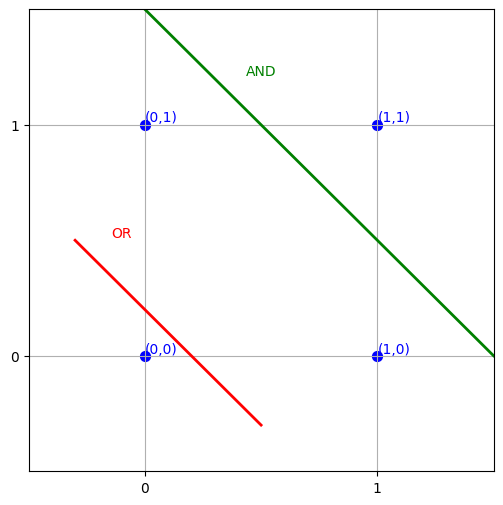

In [65]:
import matplotlib.pyplot as plt

# Coordenadas
coordinates = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Separar coordenadas x e y
x = [coord[0] for coord in coordinates]
y = [coord[1] for coord in coordinates]

# Crear el plano cartesiano
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='blue', s=50)

# Agregar etiquetas de coordenadas
for coord in coordinates:
    plt.text(coord[0], coord[1], f'({coord[0]},{coord[1]})', va='bottom', ha='left', color='blue')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xticks([0, 1])
plt.yticks([0, 1])

# Agregar líneas de cuadrícula
plt.grid(True)

# Agregar línea y etiqueta para la compuerta OR
plt.plot([-0.3, 0.5], [0.5, -0.3], 'r-', linewidth=2)
plt.text(-0.1,0.5, 'OR', va='bottom', ha='center', color='red')

# Agregar línea y etiqueta para la compuerta AND
plt.plot([0, 1.5], [1.5, 0], 'g-', linewidth=2)
plt.text(0.5, 1.2, 'AND', va='bottom', ha='center', color='green')

# Mostrar el gráfico
plt.show()

Se visualizan fronteras de decisión
* OR: separa (0,0) del resto
* AND: separa (1,1) del resto

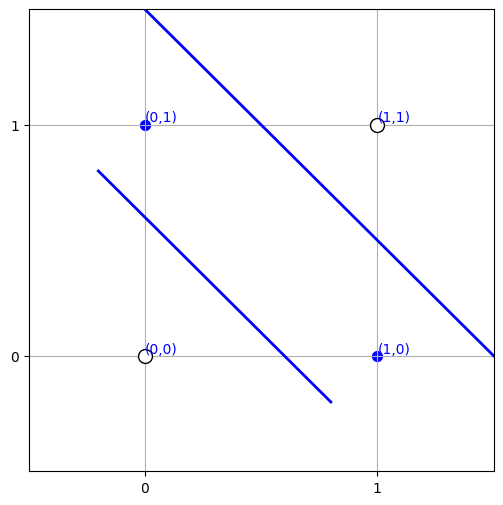

In [66]:
# Coordenadas
coordinates = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Separar coordenadas x e y
x = [coord[0] for coord in coordinates]
y = [coord[1] for coord in coordinates]

# Crear el plano cartesiano
plt.figure(figsize=(6, 6))
plt.scatter(x, y, color='blue', s=50)

# Agregar etiquetas de coordenadas
for coord in coordinates:
    plt.text(coord[0], coord[1], f'({coord[0]},{coord[1]})', va='bottom', ha='left', color='blue')

# Dibujar círculos en los puntos (0, 0) y (1, 1)
circle_coordinates = [(0, 0), (1, 1)]
circle_x = [coord[0] for coord in circle_coordinates]
circle_y = [coord[1] for coord in circle_coordinates]
plt.plot(circle_x, circle_y, 'o', color='red', markersize=10, markeredgecolor='black', markerfacecolor='white')

# Configurar límites y marcas de los ejes
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.xticks([0, 1])
plt.yticks([0, 1])

# Agregar líneas de cuadrícula
plt.grid(True)

# Agregar línea de la primera neurona
plt.plot([0, 1.5], [1.5, 0], 'b-', linewidth=2)
# Agregar línea dela segunda neurona
plt.plot([-0.2, 0.8], [0.8, -0.2], 'b-', linewidth=2)


# Mostrar el gráfico
plt.show()

* Los círculos blancos son los casos donde XOR = 0
* Cada línea representa la frontera de una neurona

La idea es:
* 1 perceptron --> no puede resolver XOR
* 2 perceptrones + una capa de salida --> sí pueden